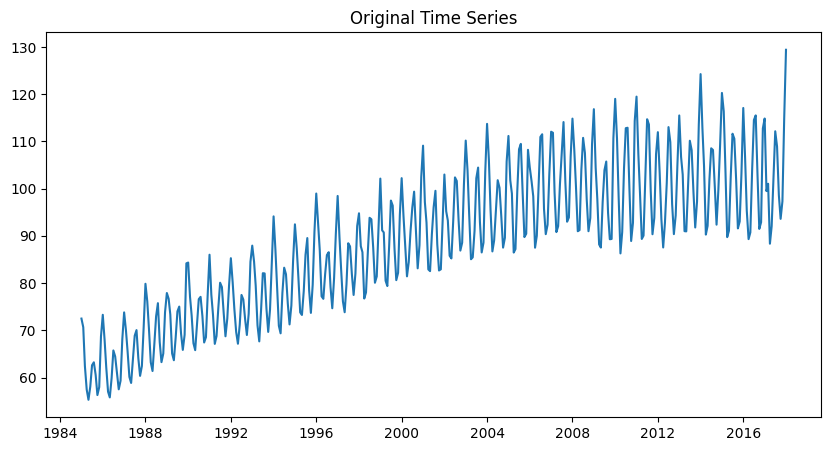

ADF Statistic: -2.25699035004725
p-value: 0.18621469116586592
Data is NOT Stationary

Differencing order (d): 1
                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                  317
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1022.680
Date:                Tue, 21 Apr 2026   AIC                           2051.361
Time:                        00:11:38   BIC                           2062.628
Sample:                    01-01-1985   HQIC                          2055.862
                         - 05-01-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0472      0.101      0.468      0.640      -0.150       0.245
ma.L1          0.57

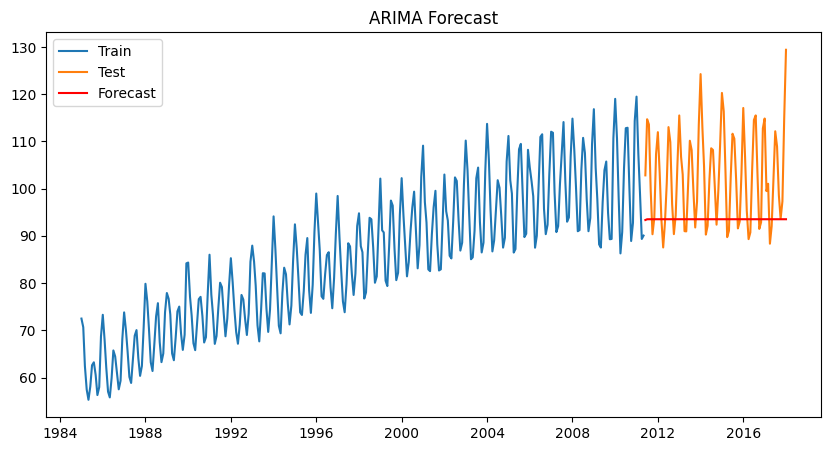


Next 10 Predictions:
2011-06-01    93.369129
2011-07-01    93.524807
2011-08-01    93.532153
2011-09-01    93.532500
2011-10-01    93.532516
2011-11-01    93.532517
2011-12-01    93.532517
2012-01-01    93.532517
2012-02-01    93.532517
2012-03-01    93.532517
Freq: MS, Name: predicted_mean, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv(r"C:\Users\NITRO V\Downloads\DAV exps\DAV code\Electric_Production.csv")

# Change these column names
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)

ts = df['IPG2211A2N']   # target column

# ==============================
# 2. VISUALIZE
# ==============================
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Original Time Series")
plt.show()

# ==============================
# 3. CHECK STATIONARITY (ADF TEST)
# ==============================
def check_stationarity(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] <= 0.05:
        print("Data is Stationary\n")
    else:
        print("Data is NOT Stationary\n")

check_stationarity(ts)

# ==============================
# 4. DIFFERENCING (if needed)
# ==============================
d = 0
ts_diff = ts.copy()

while True:
    result = adfuller(ts_diff.dropna())
    if result[1] <= 0.05:
        break
    ts_diff = ts_diff.diff()
    d += 1

print("Differencing order (d):", d)

# ==============================
# 5. TRAIN-TEST SPLIT
# ==============================
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ==============================
# 6. BUILD MODEL (You can tune p,q)
# ==============================
p = 1
q = 1

model = ARIMA(train, order=(p,d,q))
model_fit = model.fit()

print(model_fit.summary())

# ==============================
# 7. FORECAST
# ==============================
forecast = model_fit.forecast(steps=len(test))

# ==============================
# 8. EVALUATION
# ==============================
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

# ==============================
# 9. PLOT RESULTS
# ==============================
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast", color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

# ==============================
# 10. FUTURE FORECAST
# ==============================
future_steps = 10
future_forecast = model_fit.forecast(steps=future_steps)

print("\nNext 10 Predictions:")
print(future_forecast)